## INSTALL & IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px   # Used for interactive dashboards.
import plotly.graph_objects as go     #Used when dashboard becomes complex.
from plotly.subplots import make_subplots # Multiple charts in one dashboard.
import warnings


In [2]:
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14,6)
plt.rcParams["axes.facecolor"] = "darkblue"  # background
plt.rcParams["figure.facecolor"] = "black"
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"   # X-axis numbers -> white
plt.rcParams["ytick.color"] = "white"
plt.rcParams["axes.titlecolor"] = "white"

In [3]:
COLORS = ["lightblue","amber","purple","softred","teal","Deeporange","green","pink","skyblue","limegreen"]

In [4]:
IPL_BLUE = "darkblue"
IPL_GOLD = "amber"
IPL_GREEN = "green"
print("Libraries imorted successfully!")

Libraries imorted successfully!


## LOAD & PREVIEW DATA

In [5]:
df = pd.read_csv("ipl-matches.csv")

In [6]:
print("*"  * 50)
print("        IPL DATASET OVERVIEW")
print("*"  * 50)
print(f"rows:{df.shape[0]:,}")
print(f"columns : {df.shape[1]}")
print(f"Seasons: {df['Season'].nunique()} ({sorted(df['Season'].unique())[0]} - {sorted(df['Season'].unique())[-1]})")
print(f"Teams : {pd.concat([df['Team1'] , df['Team2']]).nunique()}")
print(f"Venues : {df['Venue'].nunique()}")
print(f"Cities :{df['City'].nunique()}")

print("*"  *   50)
df.head(2)

**************************************************
        IPL DATASET OVERVIEW
**************************************************
rows:950
columns : 20
Seasons: 15 (2007/08 - 2022)
Teams : 18
Venues : 49
Cities :33
**************************************************


,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


##  DATA TYPES & COLUMN INFO

In [7]:
print("column info")
df.info()
print("numeric summary")
df.describe().T

column info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team

,count,mean,std,min,25%,50%,75%,max
ID,950.0,830485.247368,337567.829494,335982.0,501261.25,829738.0,1175371.75,1312200.0
Margin,932.0,17.056867,21.633109,1.0,6.00,8.0,19.00,146.0


## DATA CLEANING AND FEATURE NGINEERING

In [8]:
df = pd.read_csv("ipl-matches.csv")

### PARSE DATES

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
print(df['Date'].head(2))
print(df['year'].head(2))
print(df['Month'].head(2))
print(df['DayOfWeek'].head(2))

0   2022-05-29
1   2022-05-27
Name: Date, dtype: datetime64[ns]
0    2022
1    2022
Name: year, dtype: int32
0    5
1    5
Name: Month, dtype: int32
0    Sunday
1    Friday
Name: DayOfWeek, dtype: object


### Normalise season to 4-digit year

In [10]:
def season_year(s):
    s = str(s)
    if '/' in s:
        return int(s.split('/')[0])
    return int(s)

df['SeasonYear'] = df['Season'].apply(season_year)
print(df['SeasonYear'])

0      2022
1      2022
2      2022
3      2022
4      2022
       ... 
945    2007
946    2007
947    2007
948    2007
949    2007
Name: SeasonYear, Length: 950, dtype: int64


### Did the toss winner also win the match

In [11]:
df['TossWinMatchWin'] = (df['TossWinner'] == df['WinningTeam']).astype(int)  # te

In [12]:
print(df['TossWinMatchWin'])

0      0
1      1
2      0
3      1
4      0
      ..
945    0
946    0
947    0
948    1
949    0
Name: TossWinMatchWin, Length: 950, dtype: int64


### Clean margin : coerce non-numric to NaN

In [13]:
Margin= pd.to_numeric(df['Margin'],errors = 'coerce')
print(Margin)

0        7.0
1        7.0
2       14.0
3        7.0
4        5.0
       ...  
945      5.0
946      5.0
947      9.0
948     33.0
949    140.0
Name: Margin, Length: 950, dtype: float64


### Fill missing city using venue

In [14]:
venue_city_map = (
    df.dropna(subset=['City'])
      .drop_duplicates(subset=['Venue'])
      .set_index('Venue')['City']
      .to_dict()
)

# print(venue_city_map)

df['City'] = df.apply(
    lambda r : venue_city_map.get(r['Venue'], r['City']) if pd.isna(r['City']) else r['City'],axis = 1
)

print(df['City'])

0       Ahmedabad
1       Ahmedabad
2         Kolkata
3         Kolkata
4          Mumbai
          ...    
945       Kolkata
946        Mumbai
947         Delhi
948    Chandigarh
949     Bangalore
Name: City, Length: 950, dtype: object


### Strip venue to short name(remove city suffix after comma)

In [15]:
VenueShort = df['Venue'].str.split(',').str[0].str.strip()
print(VenueShort.head(3))

0    Narendra Modi Stadium
1    Narendra Modi Stadium
2             Eden Gardens
Name: Venue, dtype: object


### Super over matches

In [16]:
Superover = df['SuperOver'].str.strip().str.upper().eq('Y')
print(Superover.head(3))

0    False
1    False
2    False
Name: SuperOver, dtype: bool


In [17]:
print( [c for c in df.columns if c not in
      ['ID','City','Date','Season','MatchNumber','Team1','Team2','Venue',
       'TossWinner','TossDecision','SuperOver','WinningTeam','WonBy','Margin',
       'method','Player_of_Match','Team1Players','Team2Players','Umpire1','Umpire2']])
# df[['Date','SeasonYear','VenueShort','TossWinMatchWin','IsSuperOver']].head()


['year', 'Month', 'DayOfWeek', 'SeasonYear', 'TossWinMatchWin']


In [18]:
# df[['Date','SeasonYear','VenueShort','TossWinMatchWin','IsSuperOver']].head()


## Missing value analysis

In [19]:
IPL_BLUE = '#1a1a2e'
IPL_GOLD = '#f9a825'

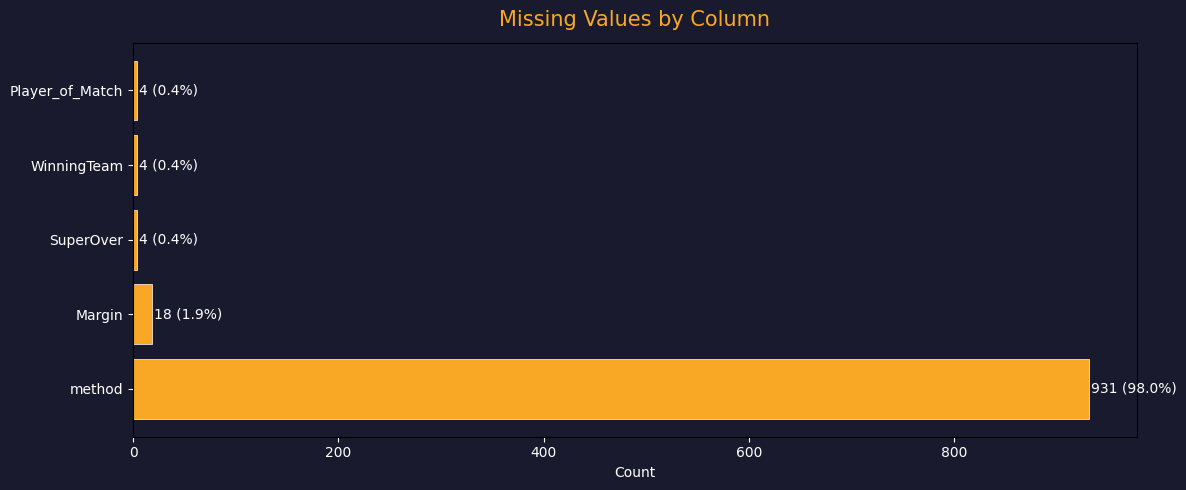

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
miss = df.isnull().sum().sort_values(ascending=False)
miss = miss[miss > 0]
bars = ax.barh(miss.index, miss.values, color=IPL_GOLD, edgecolor='#fff', linewidth=0.5)
for bar, val in zip(bars, miss.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)', va='center', color='white', fontsize=10)
ax.set_title('Missing Values by Column', fontsize=15, color=IPL_GOLD, pad=12)
ax.set_xlabel('Count')
ax.set_facecolor(IPL_BLUE)
fig.patch.set_facecolor(IPL_BLUE)
plt.tight_layout()
plt.savefig('01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()             

## Numpy statistical analysis 

In [21]:
runs_arr = df[df['WonBy'] == 'Runs']['Margin'].dropna().values
wickets_arr = df[df['WonBy'] == 'Wickets']['Margin'].dropna().values

print("*" * 50)
print("NUMPY STATS -- WIN BY RUNS")
print("*" * 50)

print(f"count : {len(runs_arr)}")
print(f"mean : {np.mean(runs_arr):.2f}")
print(f"Median : {np.median(runs_arr):.2f}")
print(f"Std Dev : {np.std(runs_arr):.2f}")
print(f"Min : {np.min(runs_arr)}")
print(f"Max : {np.max(runs_arr)}")
print(f"25th %: {np.percentile(runs_arr,25):.1f}")
print(f"75th % : {np.percentile(runs_arr,75):.1f}")
print("\n" + "*" * 45)
print("NUMPY STATS -- WIN BY WICKETS")
print("*" * 45)
print(f"count : {len(wickets_arr)}")
print(f"mean : {np.mean(wickets_arr):.2f}")
print(f"median : {np.median(wickets_arr):.2f}")
print(f"std dev : {np.std(wickets_arr):.2f}")
print(f"min : {np.min(wickets_arr)}")
print(f"max : {np.max(wickets_arr)}")

**************************************************
NUMPY STATS -- WIN BY RUNS
**************************************************
count : 423
mean : 30.07
Median : 22.00
Std Dev : 26.75
Min : 1.0
Max : 146.0
25th %: 11.0
75th % : 41.0

*********************************************
NUMPY STATS -- WIN BY WICKETS
*********************************************
count : 509
mean : 6.24
median : 6.00
std dev : 1.83
min : 1.0
max : 10.0


###  Correlation matrix using pandas (handles NaN cleanly)

In [22]:
corr_df = df[['SeasonYear','Margin','TossWinMatchWin']].dropna()
corr_matrix = np.corrcoef(corr_df.values.T)
print("Correlation matrix (Season/Margin/TosswinMatchWin): ")

print(pd.DataFrame(corr_matrix, index= corr_df.columns,columns = corr_df.columns).round(3))

Correlation matrix (Season/Margin/TosswinMatchWin): 
                 SeasonYear  Margin  TossWinMatchWin
SeasonYear            1.000  -0.019            0.013
Margin               -0.019   1.000           -0.169
TossWinMatchWin       0.013  -0.169            1.000


## Matches per session

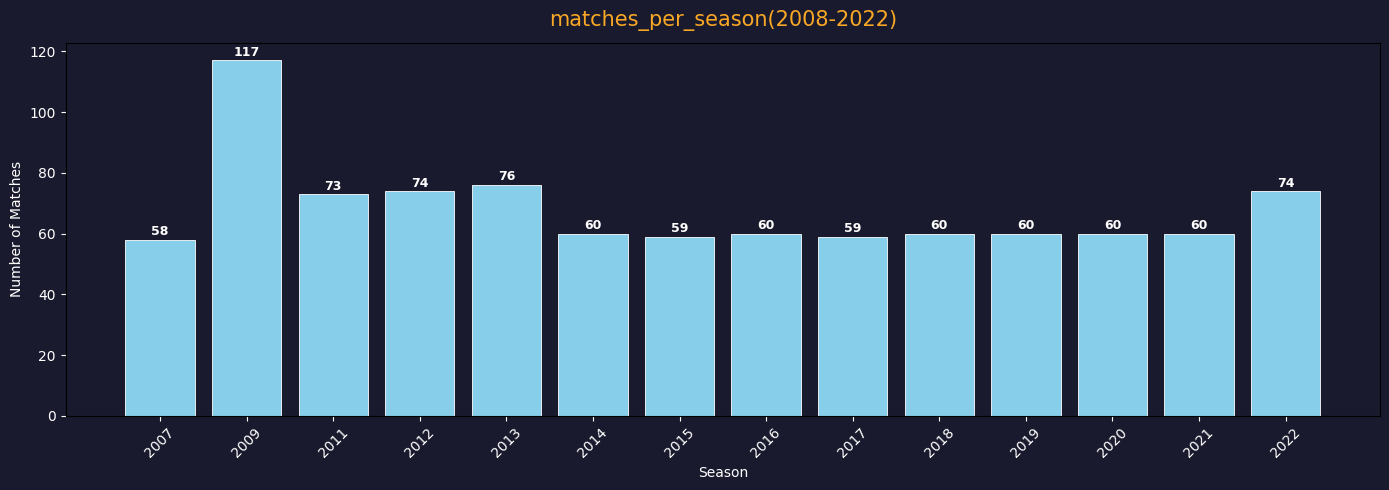

In [23]:
matches_per_season = df.groupby('SeasonYear').size().reset_index(name='Matches')

fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(matches_per_season['SeasonYear'].astype(str), 
              matches_per_season['Matches'],color = "skyblue", edgecolor= "white",linewidth= 0.6)

for bar, val in zip(bars, matches_per_season['Matches']):
    ax.text(bar.get_x() + bar.get_width()/2,bar.get_height()+ 0.5 , 
           str(val), ha= "center", va = "bottom",color = "white",fontsize = 9,fontweight="bold")

ax.set_title('matches_per_season(2008-2022)',fontsize=15,color=IPL_GOLD,pad = 12)
ax.set_xlabel('Season')
ax.set_ylabel('Number of Matches')
ax.set_facecolor(IPL_BLUE)
fig.patch.set_facecolor(IPL_BLUE)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig('02_matches_per_season.png', dpi=150,bbox_inches= 'tight')
plt.show()

## Team Win Analysis

In [24]:
team_wins = (df.dropna(subset= ['WinningTeam'])
               .groupby('WinningTeam')
               .size()
               .sort_values(ascending = False)
               .reset_index(name= "Wins"))
                           

### total matches played

In [25]:
team1 = df.groupby('Team1').size()
team2 = df.groupby('Team2').size()
total_played = (team1.add(team2,fill_value=0)).reset_index()
total_played.columns = ['Team', 'Played']
team_wins = team_wins.rename(columns= {'WinningTeam':'Team'})
team_wins = team_wins.merge(total_played, on= 'Team')
team_wins['WinRate'] = (team_wins['Wins']/ team_wins['Played'] *100).round(1)
team_wins['Losses'] = team_wins['Played'] - team_wins['Wins']
print(team_wins.to_string(index = False))

                       Team  Wins  Played  WinRate  Losses
             Mumbai Indians   131     231     56.7     100
        Chennai Super Kings   121     208     58.2      87
      Kolkata Knight Riders   114     223     51.1     109
Royal Challengers Bangalore   109     226     48.2     117
           Rajasthan Royals    96     192     50.0      96
            Kings XI Punjab    88     190     46.3     102
        Sunrisers Hyderabad    75     152     49.3      77
           Delhi Daredevils    67     161     41.6      94
             Delhi Capitals    36      63     57.1      27
            Deccan Chargers    29      75     38.7      46
              Gujarat Lions    13      30     43.3      17
               Punjab Kings    13      28     46.4      15
             Gujarat Titans    12      16     75.0       4
              Pune Warriors    12      46     26.1      34
     Rising Pune Supergiant    10      16     62.5       6
       Lucknow Super Giants     9      15     60.0      

### Chart of Top 10 Teams

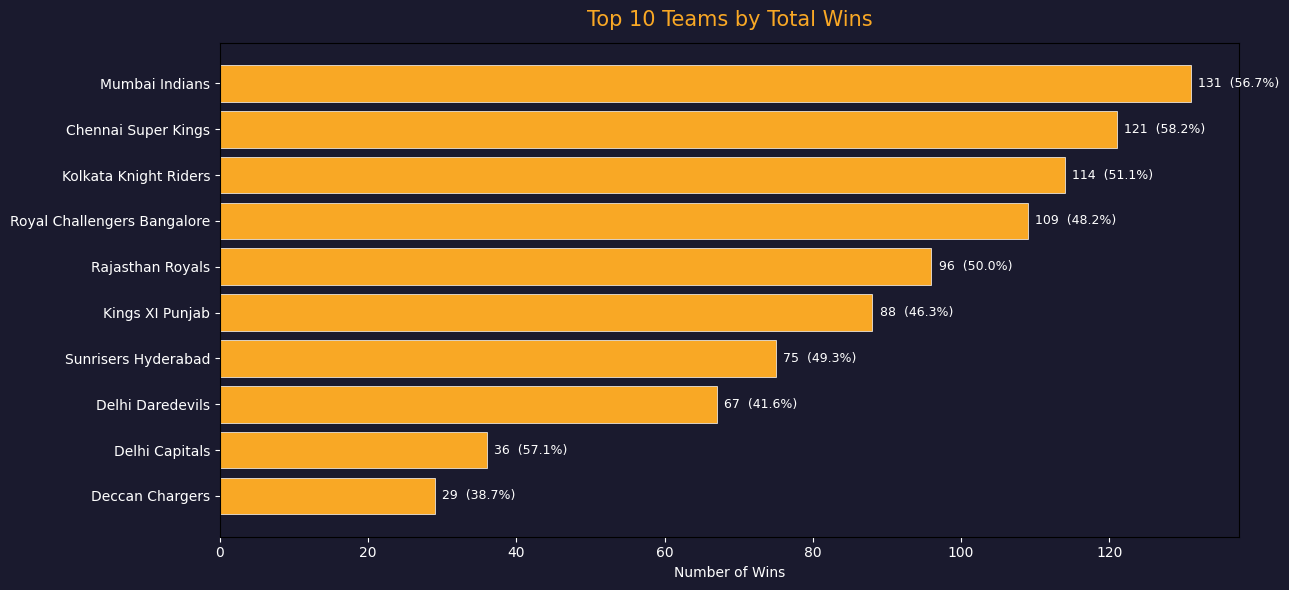

In [26]:
top10 = team_wins.head(10)
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top10['Team'][::-1], top10['Wins'][::-1],
               color=IPL_GOLD[:10], edgecolor='white', linewidth=0.5)
for bar, val, wr in zip(bars, top10['Wins'][::-1], top10['WinRate'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}  ({wr}%)', va='center', color='white', fontsize=9)
ax.set_title('Top 10 Teams by Total Wins', fontsize=15, color=IPL_GOLD, pad=12)
ax.set_xlabel('Number of Wins')
ax.set_facecolor(IPL_BLUE)
fig.patch.set_facecolor(IPL_BLUE)
plt.tight_layout()
plt.savefig('03_team_wins.png', dpi=150, bbox_inches='tight')
plt.show()
 


## TOSS ANALYSIS

### Toss decision distribution

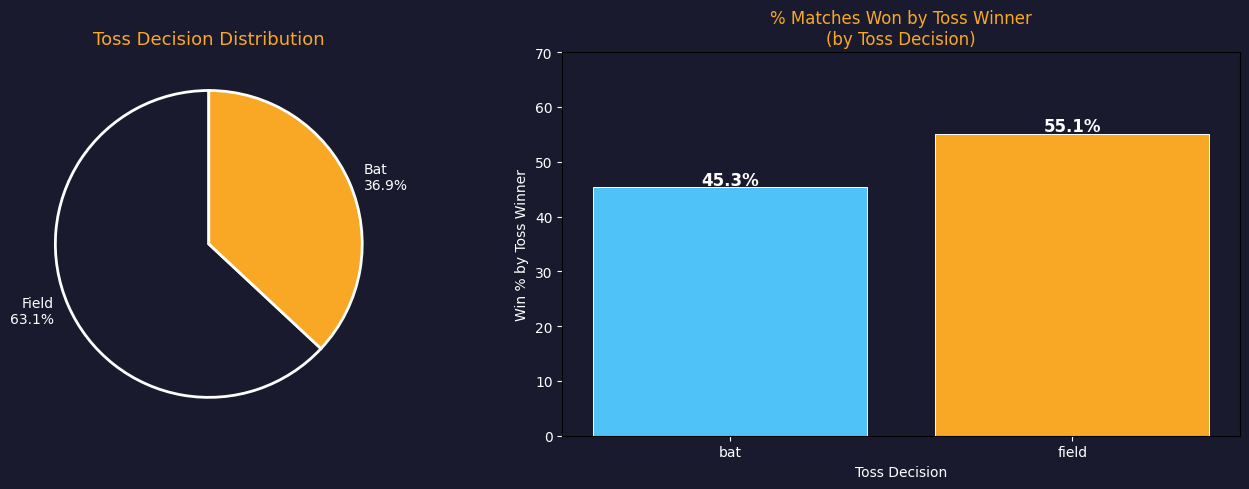

In [27]:
toss_dec = df['TossDecision'].value_counts()
fig, axes= plt.subplots(1,2,figsize =(14,5))

 # pie chart

axes[0].pie(toss_dec.values, labels=[f'{l.title()}\n{v/toss_dec.sum()*100:.1f}%'
            for l, v in zip(toss_dec.index, toss_dec.values)],
            colors=[IPL_BLUE,IPL_GOLD], startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})


axes[0].set_title('Toss Decision Distribution',fontsize=13, color= IPL_GOLD)
axes[0].set_facecolor(IPL_BLUE)

# toss winner == match winer or not ?

toss_effect = df.groupby('TossDecision')['TossWinMatchWin'].mean()*100
axes[1].bar(toss_effect.index, toss_effect.values, color=['#4fc3f7','#f9a825'],
            edgecolor='white', linewidth=0.7)
for i, (idx, val) in enumerate(toss_effect.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('% Matches Won by Toss Winner\n(by Toss Decision)', fontsize=12, color=IPL_GOLD)
axes[1].set_xlabel('Toss Decision')
axes[1].set_ylabel('Win % by Toss Winner')
axes[1].set_ylim(0, 70)
axes[1].set_facecolor(IPL_BLUE)
 
for ax in axes:
    ax.tick_params(colors='white')

fig.patch.set_facecolor(IPL_BLUE)
plt.tight_layout()
plt.savefig('04_toss_analysis.png' ,dpi =150 ,bbox_inches='tight')
plt.show

overall_toss_win_pct = df['TossWinMatchWin'].mean()*100

## Win type Analysis (Runs vs Wicket)

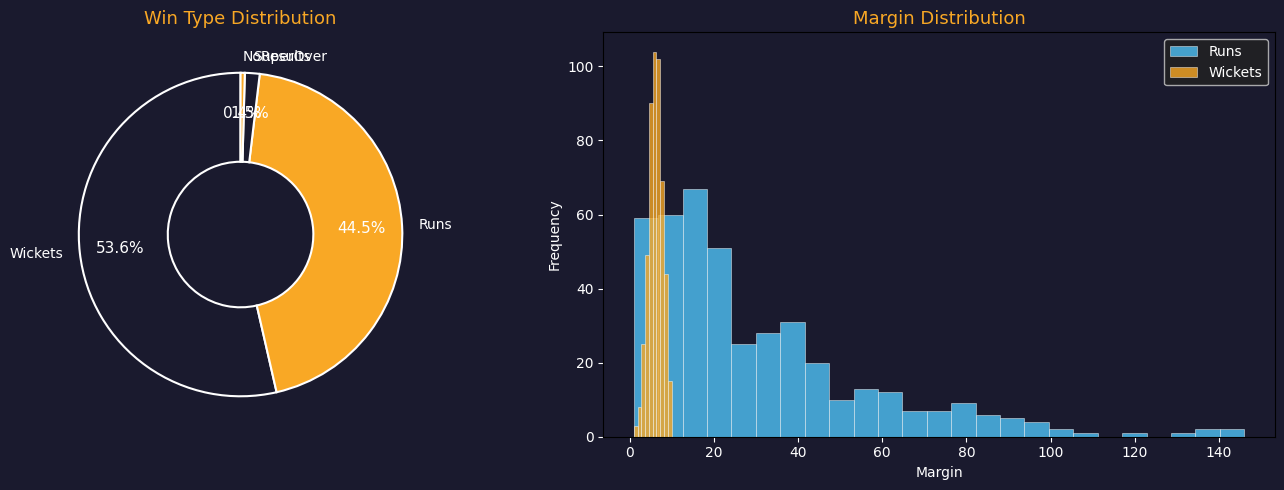

In [28]:
won_by_counts = df['WonBy'].value_counts()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Donut
wedges, texts, autotexts = axes[0].pie(
    won_by_counts.values,
    labels=won_by_counts.index,
    autopct='%1.1f%%',
    colors=[IPL_BLUE, IPL_GOLD],
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':1.5,'width':0.55}
)
for t in autotexts: t.set_color('white'); t.set_fontsize(11)
axes[0].set_title('Win Type Distribution', fontsize=13, color=IPL_GOLD)
 
# Margin distribution
runs_data    = df[df['WonBy'] == 'Runs']['Margin'].dropna()
wickets_data = df[df['WonBy'] == 'Wickets']['Margin'].dropna()
axes[1].hist(runs_data, bins=25, alpha=0.8, color='#4fc3f7', label='Runs', edgecolor='white', linewidth=0.4)
axes[1].hist(wickets_data, bins=10, alpha=0.8, color='#f9a825', label='Wickets', edgecolor='white', linewidth=0.4)
axes[1].set_title('Margin Distribution', fontsize=13, color=IPL_GOLD)
axes[1].set_xlabel('Margin')
axes[1].set_ylabel('Frequency')
axes[1].legend(facecolor='#222', labelcolor='white')
axes[1].set_facecolor(IPL_BLUE)
 
for ax in axes:
    ax.set_facecolor(IPL_BLUE)
    ax.tick_params(colors='white')
fig.patch.set_facecolor(IPL_BLUE)
plt.tight_layout()
plt.savefig('05_win_type.png', dpi=150, bbox_inches='tight')
plt.show()


## VENUE ANALYSIS

In [29]:
# Create VenueShort column

df['VenueShort'] = (
    df['Venue']
      .astype(str)
      .str.split(',')
      .str[0]
      .str.strip()
)

print(df[['Venue','VenueShort']].head())

                              Venue             VenueShort
0  Narendra Modi Stadium, Ahmedabad  Narendra Modi Stadium
1  Narendra Modi Stadium, Ahmedabad  Narendra Modi Stadium
2             Eden Gardens, Kolkata           Eden Gardens
3             Eden Gardens, Kolkata           Eden Gardens
4          Wankhede Stadium, Mumbai       Wankhede Stadium


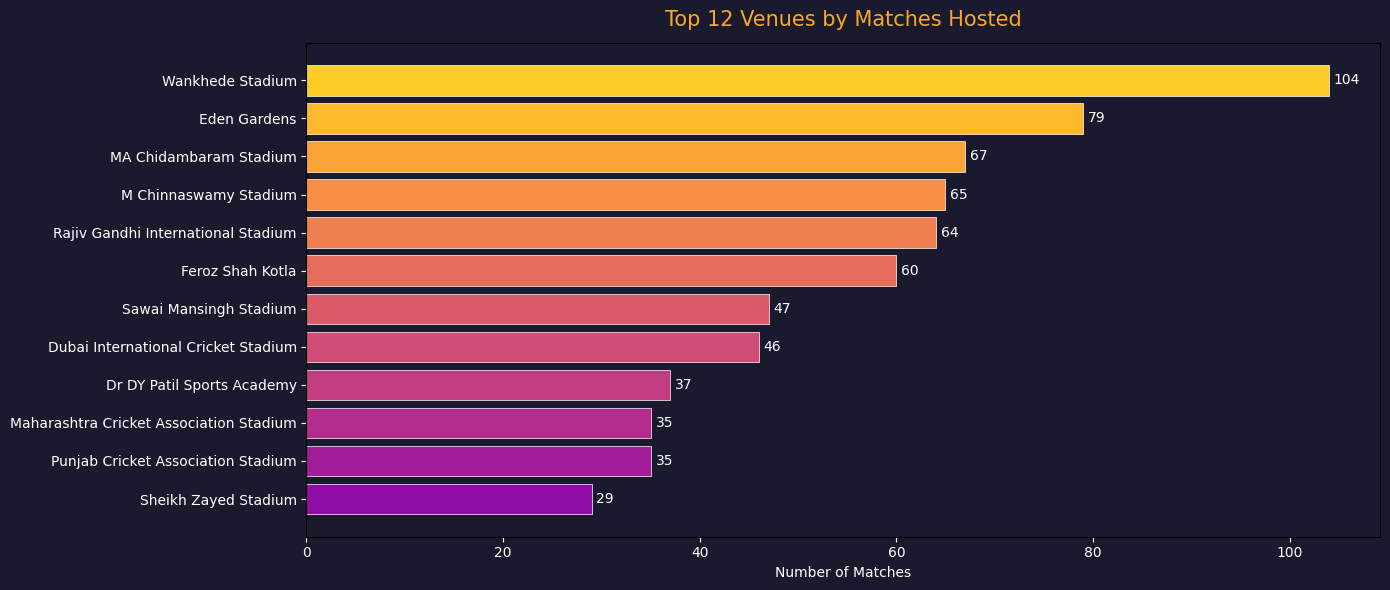

In [30]:
venue_matches = df.groupby('VenueShort').size().sort_values(ascending=False).head(12)
 
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(venue_matches.index[::-1], venue_matches.values[::-1],
               color=plt.cm.plasma(np.linspace(0.3, 0.9, len(venue_matches))), edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, venue_matches.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='white', fontsize=10)
ax.set_title('Top 12 Venues by Matches Hosted', fontsize=15, color=IPL_GOLD, pad=12)
ax.set_xlabel('Number of Matches')
ax.set_facecolor(IPL_BLUE)
fig.patch.set_facecolor(IPL_BLUE)
plt.tight_layout()
plt.savefig('06_venue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Player Of the Match Analysis

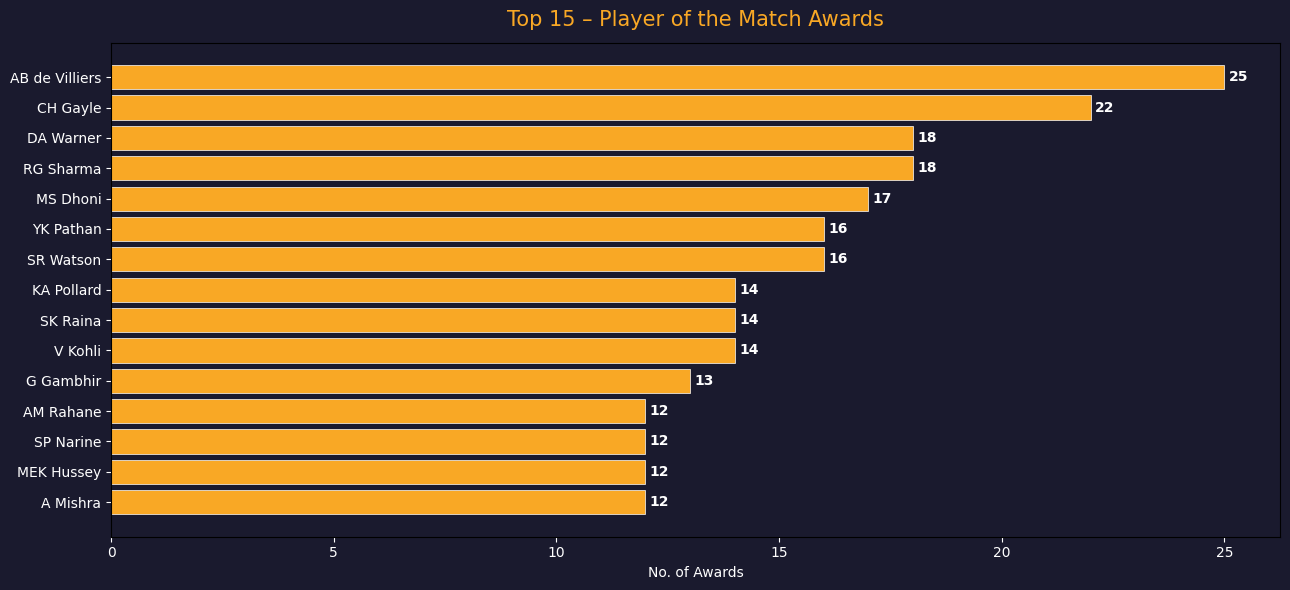

        Player  Awards
AB de Villiers      25
      CH Gayle      22
     DA Warner      18
     RG Sharma      18
      MS Dhoni      17
     YK Pathan      16
     SR Watson      16
    KA Pollard      14
      SK Raina      14
       V Kohli      14
     G Gambhir      13
     AM Rahane      12
     SP Narine      12
    MEK Hussey      12
      A Mishra      12


In [31]:
potm = df['Player_of_Match'].value_counts().head(15).reset_index()
potm.columns = ['Player', 'Awards']
 
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(potm['Player'][::-1], potm['Awards'][::-1],
               color=IPL_GOLD, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, potm['Awards'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='white', fontsize=10, fontweight='bold')
ax.set_title('Top 15 – Player of the Match Awards', fontsize=15, color=IPL_GOLD, pad=12)
ax.set_xlabel('No. of Awards')
ax.set_facecolor(IPL_BLUE)
fig.patch.set_facecolor(IPL_BLUE)
plt.tight_layout()
plt.savefig('07_potm.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(potm.to_string(index=False))


## Team Performance over the year (Line chart)

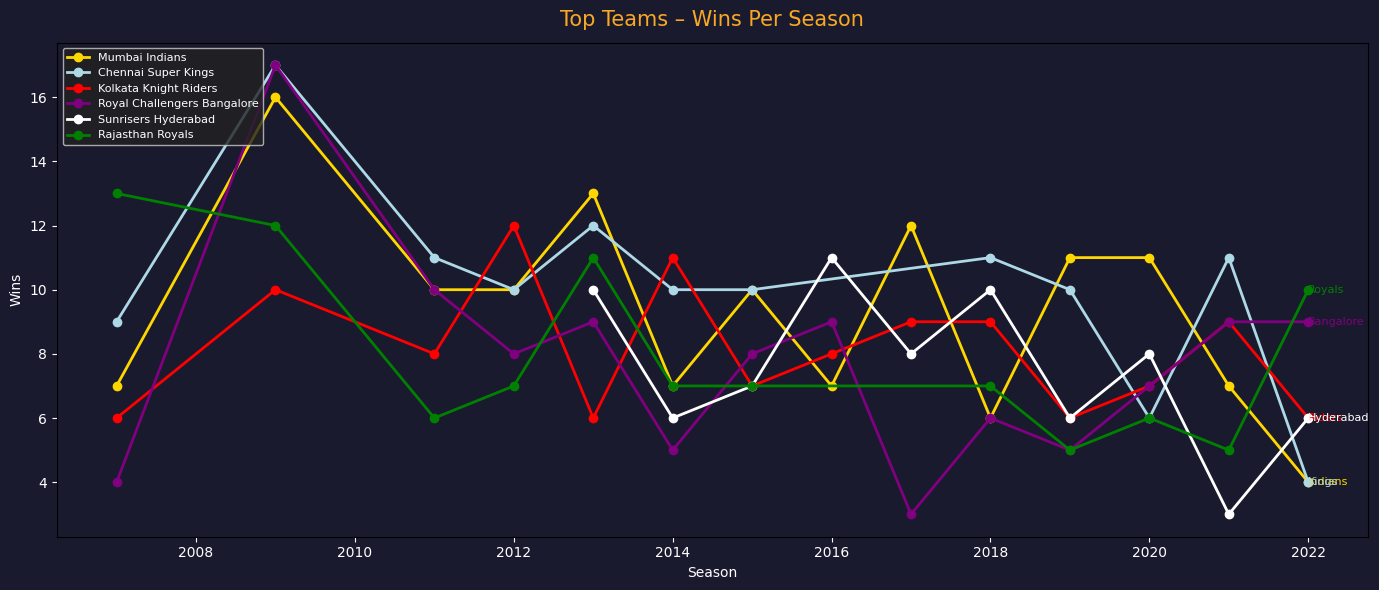

In [32]:
TOP_TEAMS = ['Mumbai Indians', 'Chennai Super Kings', 'Kolkata Knight Riders',
             'Royal Challengers Bangalore', 'Sunrisers Hyderabad', 'Rajasthan Royals']
 
wins_season = (df[df['WinningTeam'].isin(TOP_TEAMS)]
               .groupby(['SeasonYear', 'WinningTeam'])
               .size()
               .reset_index(name='Wins'))
 
fig, ax = plt.subplots(figsize=(14, 6))
palette = dict(zip(TOP_TEAMS, ["gold","lightblue","red","purple","white","green"]))
for team in TOP_TEAMS:
    data = wins_season[wins_season['WinningTeam'] == team]
    ax.plot(data['SeasonYear'], data['Wins'], marker='o', linewidth=2,
            label=team, color=palette[team])
    ax.annotate(team.split()[-1], xy=(data['SeasonYear'].iloc[-1], data['Wins'].iloc[-1]),
                color=palette[team], fontsize=8, va='center')
 
ax.set_title('Top Teams – Wins Per Season', fontsize=15, color=IPL_GOLD, pad=12)
ax.set_xlabel('Season')
ax.set_ylabel('Wins')
ax.legend(facecolor='#222', labelcolor='white', fontsize=8, loc='upper left')
ax.set_facecolor(IPL_BLUE)
fig.patch.set_facecolor(IPL_BLUE)
plt.tight_layout()
plt.savefig('08_team_over_years.png', dpi=150, bbox_inches='tight')
plt.show()


## Average Margin By Season

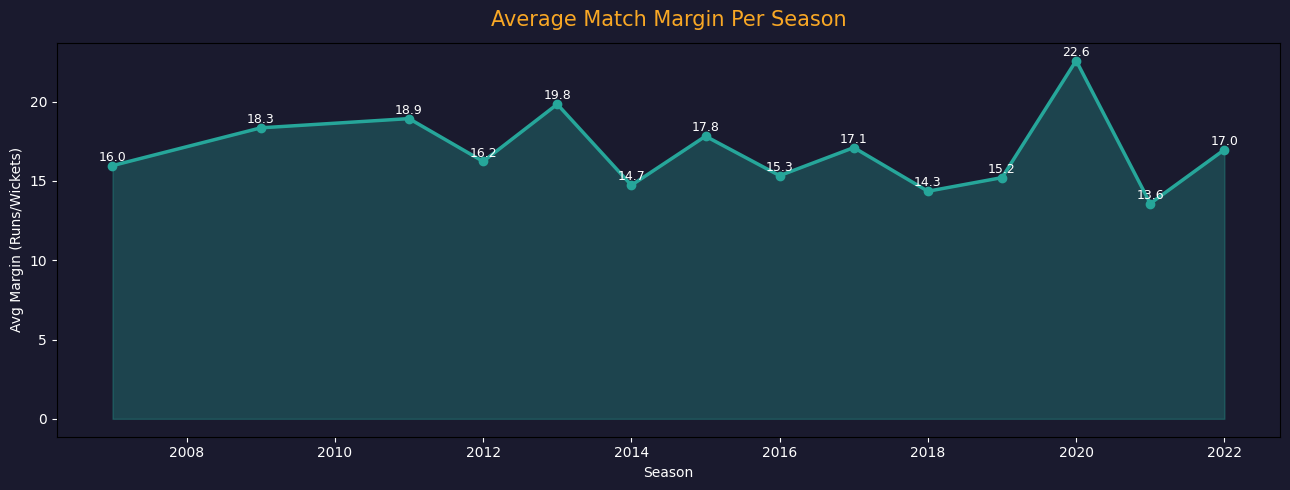

In [33]:
avg_margin = df.groupby('SeasonYear')['Margin'].mean().reset_index()
avg_margin.columns = ['Season', 'AvgMargin']
 
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(avg_margin['Season'], avg_margin['AvgMargin'], alpha=0.3, color='#26a69a')
ax.plot(avg_margin['Season'], avg_margin['AvgMargin'], color='#26a69a',
        linewidth=2.5, marker='o')
for _, row in avg_margin.iterrows():
    ax.text(row['Season'], row['AvgMargin'] + 0.3, f"{row['AvgMargin']:.1f}",
            ha='center', color='white', fontsize=9)
ax.set_title('Average Match Margin Per Season', fontsize=15, color=IPL_GOLD, pad=12)
ax.set_xlabel('Season')
ax.set_ylabel('Avg Margin (Runs/Wickets)')
ax.set_facecolor(IPL_BLUE)
fig.patch.set_facecolor(IPL_BLUE)
plt.tight_layout()
plt.savefig('09_avg_margin.png', dpi=150, bbox_inches='tight')
plt.show()


## Super Over Matches

In [34]:
df['IsSuperOver'] = (
    df.SuperOver
      .astype(str)
      .str.strip()
      .str.upper()
      .eq('Y')
)

In [35]:
so_matches = df[df['IsSuperOver'] == True].copy()
print(f"Total Super Over matches: {len(so_matches)}")
print("Super Over matches by season:")
print(so_matches.groupby('SeasonYear').size().reset_index(name='SuperOvers').to_string(index=False))
print("Teams in Super Overs (most involved):")
so_teams = pd.concat([so_matches['Team1'], so_matches['Team2']]).value_counts().head(8)
print(so_teams)


Total Super Over matches: 14
Super Over matches by season:
 SeasonYear  SuperOvers
       2009           2
       2013           2
       2014           1
       2015           1
       2017           1
       2019           2
       2020           4
       2021           1
Teams in Super Overs (most involved):
Kolkata Knight Riders          4
Mumbai Indians                 4
Sunrisers Hyderabad            4
Kings XI Punjab                4
Delhi Capitals                 3
Royal Challengers Bangalore    3
Rajasthan Royals               3
Gujarat Lions                  1
Name: count, dtype: int64


## Match Day Distribution

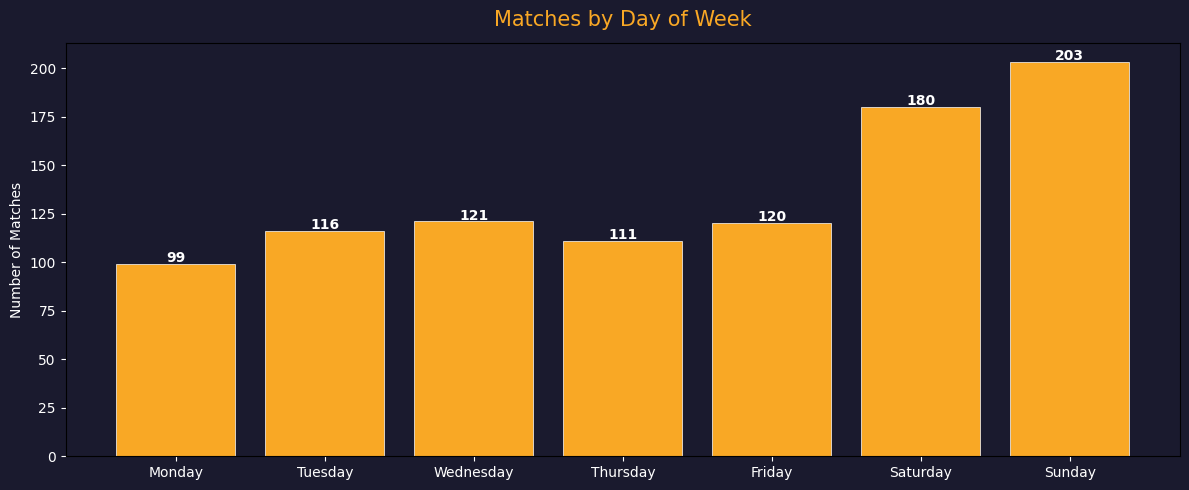

In [36]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_dist  = df['DayOfWeek'].value_counts().reindex(day_order, fill_value=0)
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(day_dist.index, day_dist.values, color=IPL_GOLD[:7], edgecolor='white', linewidth=0.5)
for i, val in enumerate(day_dist.values):
    ax.text(i, val + 1, str(val), ha='center', color='white', fontsize=10, fontweight='bold')
ax.set_title('Matches by Day of Week', fontsize=15, color=IPL_GOLD, pad=12)
ax.set_ylabel('Number of Matches')
ax.set_facecolor(IPL_BLUE)
fig.patch.set_facecolor(IPL_BLUE)
plt.tight_layout()
plt.savefig('10_day_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



## Head -To- Head Heat map(top- 8 team)

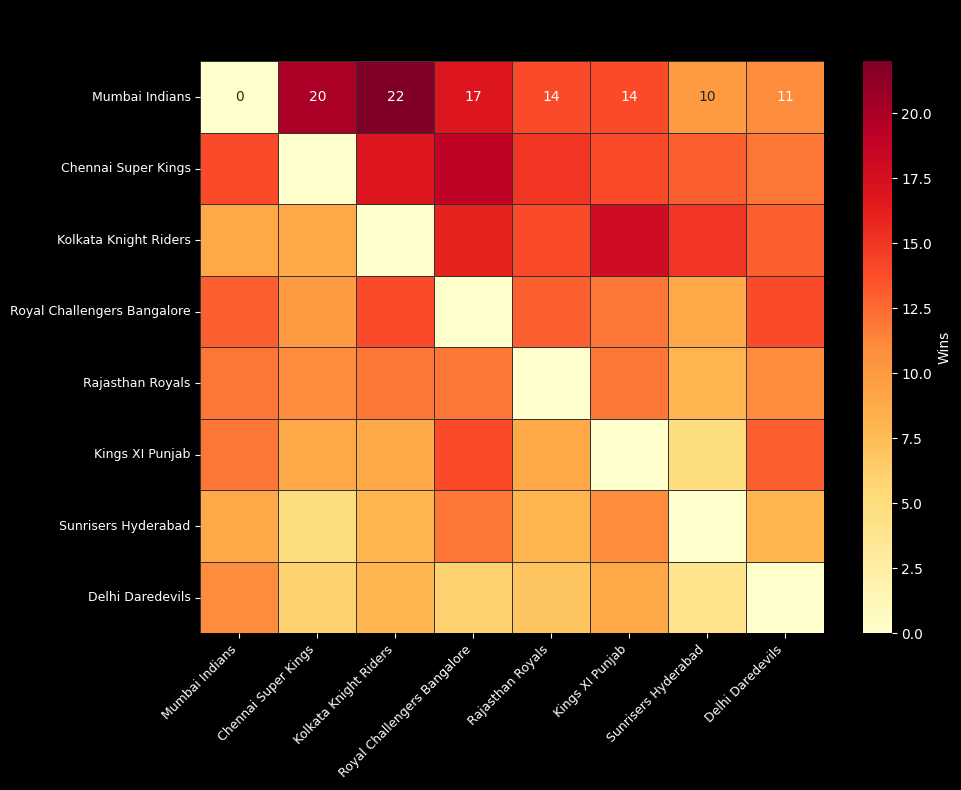

In [37]:
top8 = team_wins.head(8)['Team'].tolist()
h2h  = pd.DataFrame(0, index=top8, columns=top8)
 
for _, row in df.dropna(subset=['WinningTeam']).iterrows():
    w = row['WinningTeam']
    l = row['Team1'] if row['Team2'] == w else row['Team2']
    if w in top8 and l in top8:
        h2h.loc[w, l] += 1
 
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(h2h, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            linecolor='#333', ax=ax, cbar_kws={'label': 'Wins'})
ax.set_title('Head-to-Head Win Matrix (Top 8 Teams)\n[Row = Winner, Col = Loser]',
             fontsize=13, color='black', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('11_h2h_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
 
